In [8]:
from tqdm import tqdm
import jiwer
import os
import torch
from transformers import AutoModelForSpeechSeq2Seq, AutoProcessor, pipeline

In [9]:
txt_dir = "../data/converted/thai-central-to-vctk/txt"
wav_dir = "../data/converted/thai-central-to-vctk/wav16_silence_trimmed"

In [10]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32

model_id = "openai/whisper-large-v3"

model = AutoModelForSpeechSeq2Seq.from_pretrained(
    model_id, torch_dtype=torch_dtype, low_cpu_mem_usage=True, use_safetensors=True
)
model.to(device)

processor = AutoProcessor.from_pretrained(model_id)

pipe = pipeline(
    "automatic-speech-recognition",
    model=model,
    tokenizer=processor.tokenizer,
    feature_extractor=processor.feature_extractor,
    torch_dtype=torch_dtype,
    device=device,
)


Device set to use cuda:0


In [11]:
class CustomDataset:
    def __init__(self, txt_dir, wav_dir):
        self.txt_dir = txt_dir
        self.wav_dir = wav_dir
        self.txts = []
        self.wav_files = []
        for speaker in tqdm(os.listdir(txt_dir)):
            for filename in os.listdir(os.path.join(txt_dir, speaker)):
                filename = filename.split(".")[0]
                txt_file = os.path.join(txt_dir, speaker, filename + ".txt")
                wav_file = os.path.join(wav_dir, speaker, filename + ".flac")
                if os.path.exists(txt_file) and os.path.exists(wav_file):
                    with open(txt_file, "r") as f:
                        txt = f.read()
                    self.txts.append(txt)
                    self.wav_files.append(wav_file)

    def __len__(self):
        return len(self.txts)

    def __getitem__(self, idx):
        return self.txts[idx], self.wav_files[idx]

In [12]:
dataset = CustomDataset(txt_dir, wav_dir)

100%|██████████| 984/984 [00:41<00:00, 23.91it/s]


In [13]:
print(dataset[0])

('ปู่ขายน้ำมัลเบอร์รี่หนึ่งร้อยเปอร์เซ็นวังภูหมอกฟาร์มขวดละหนึ่งแสนหนึ่งหมื่นบาทค่ะ', '../data/converted/thai-central-to-vctk/wav16_silence_trimmed/tc0864/thai-central_201353_mic1.flac')


In [14]:
preset_batch_size = 32
dataloader = torch.utils.data.DataLoader(dataset, batch_size=preset_batch_size, shuffle=False)

In [15]:
for batch in dataloader:
    print(batch)
    break

[('ปู่ขายน้ำมัลเบอร์รี่หนึ่งร้อยเปอร์เซ็นวังภูหมอกฟาร์มขวดละหนึ่งแสนหนึ่งหมื่นบาทค่ะ', 'นายชัยพันธ์ประภาสะวัติผู้อำนวยการสถาบันเพื่อสิทธิชุมชนกล่าวว่าปัจจุบันมีสิ่งปลูกสร้างบริเวณเชิงดอยสุเทพเป็นจำนวนมากไม่เว้นแม้แต่คณะเกษตรศาสตร์', 'ความดัดจริตทั้งหมดของผู้ดีเก่าที่ผมยกเป็นตัวอย่างมานี้ไม่ใช่ประสบการณ์ตรงของผมนะครับผมเที่ยวเก็บจากโน่นจากนี่เท่านั้นเพราะตั้งแต่เกิดมายังไม่เคยเจอะเจอผู้ดีเก่าฝรั่งสักคน', 'ขอบคุณทุกความเห็นนะครับขอบคุณมากครับ', 'กรรมการได้ทำการปรึกษากันชั่วขณะหนึ่ง', 'แล้วพวกเราล่ะไม่ชวนบ้างหรือเจาะจงชวนแต่คุณนุชนะป๊ะดอกเตอร์ร์ร์', 'ดังนั้นทางออกเดียวของเขาในตอนนี้คือต้องรีบหนีเข้าไปภายในเมืองครีกทาวน์', 'นอกจากเขื่อนป่าสักชลสิทธิ์จะทำการกักเก็บน้ำแล้วยังเป็นสถานที่ท่องเที่ยวสำคัญของจังหวัดลพบุรีซึ่งทางด้านสถานที่ท่องเที่ยวในบริเวณเขื่อนป่าสักชลสิทธิ์มีหลากหลาย', 'ใครว่าล่ะแล้วลือตอนไหนทำไมเงียบจัง', 'จอร์จิน่าก็คือหนิงเจียว', 'ก็ออกมาแต่งวางตามตู้กระจกทั้งตู้กลางห้องตู้ติดผนังและตู้โชว์หน้าร้านอันเป็นกิจวัตรประจำทุกค่ำเช้าที่ทั้งนายจ้างและหล่อนจะต้องทำเมื่อมาถึงและเมื่อ

In [9]:
import warnings
warnings.filterwarnings("ignore")


In [ ]:
out_dir = './transcribed.txt'
batch_counter = 0
txts = []
transcripts = []
filenames = []

for batch in tqdm(dataloader, desc="Transcribing"):
    batch_size = len(batch[1])  # Get the actual batch size
    try:
        transcribed = pipe(list(batch[1]), batch_size=batch_size, generate_kwargs={"language": "thai"})  # Assuming batch[1] contains audio data
        transcripts.extend(["".join(t['text'].split()) for t in transcribed])
    except Exception as e:
        print(f"Error in batch {batch_counter}: {e}")
        transcripts.extend([-1] * batch_size)  # Fallback for errors
    
    filenames.extend(batch[1])
    txts.extend(["".join(t.split()) for t in list(batch[0])])  # Assuming batch[0] contains reference texts

    # Write to file every 20 batches
    if batch_counter % 20 == 0 and batch_counter > 0:
        with open(out_dir, "a") as f:
            for filename, txt, transcript in zip(filenames, txts, transcripts):
                f.write(f"{filename}|{txt}|{transcript}\n")
        
        txts.clear()
        transcripts.clear()
        filenames.clear()

    batch_counter += 1

# Write any remaining data after the loop
if txts:
    with open(out_dir, "a") as f:
        for filename, txt, transcript in zip(filenames, txts, transcripts):
            f.write(f"{filename}|{txt}|{transcript}\n")


Transcribing:   0%|          | 15/7033 [01:52<11:11:46,  5.74s/it]

Error in batch 14: The elements of the batch contain different keys. Cannot batch them ({'input_features', 'attention_mask', 'is_last'} != {'input_features', 'num_frames', 'attention_mask', 'is_last'})


Transcribing:   1%|          | 86/7033 [10:32<10:38:22,  5.51s/it]

Error in batch 85: The elements of the batch contain different keys. Cannot batch them ({'input_features', 'attention_mask', 'is_last'} != {'input_features', 'num_frames', 'attention_mask', 'is_last'})


Transcribing:   5%|▌         | 379/7033 [47:37<10:15:00,  5.55s/it]

...

Transcribing:  97%|█████████▋| 6835/7033 [13:58:48<13:33,  4.11s/it]

Error in batch 6834: The elements of the batch contain different keys. Cannot batch them ({'input_features', 'attention_mask', 'is_last'} != {'input_features', 'num_frames', 'attention_mask', 'is_last'})


Transcribing:  97%|█████████▋| 6854/7033 [14:00:28<14:45,  4.95s/it]

Error in batch 6853: The elements of the batch contain different keys. Cannot batch them ({'input_features', 'attention_mask', 'is_last'} != {'input_features', 'num_frames', 'attention_mask', 'is_last'})


Transcribing: 100%|██████████| 7033/7033 [14:20:33<00:00,  7.34s/it]


In [1]:
import pandas as pd

df = pd.read_csv('transcribed.txt', sep='|', header=None)
df.columns = ['filename', 'txt', 'transcript']
df

,filename,txt,transcript
0,../data/converted/thai-central-to-vctk/wav16_s...,ปู่ขายน้ำมัลเบอร์รี่หนึ่งร้อยเปอร์เซ็นวังภูหมอ...,ผ่านน้ำบันเบอรี่100%วางฟูหมอกความขวดละ1จน1หมื่...
1,../data/converted/thai-central-to-vctk/wav16_s...,นายชัยพันธ์ประภาสะวัติผู้อำนวยการสถาบันเพื่อสิ...,นายชายพันธ์ประพาสวัสดิ์ผู้อำนวยการสถาบันเพื่อส...
2,../data/converted/thai-central-to-vctk/wav16_s...,ความดัดจริตทั้งหมดของผู้ดีเก่าที่ผมยกเป็นตัวอย...,ความรัจจริตทั้งหมดของผู้ดีเก่าที่ผมยกเป็นตัวอย...
3,../data/converted/thai-central-to-vctk/wav16_s...,ขอบคุณทุกความเห็นนะครับขอบคุณมากครับ,ขอบคุณทุกความเห็นนะครับขอบคุณมากครับ
4,../data/converted/thai-central-to-vctk/wav16_s...,กรรมการได้ทำการปรึกษากันชั่วขณะหนึ่ง,กรรมการได้ทำการฝึกษากันชั่วขณะหนึ่ง
...,...,...,...
225023,../data/converted/thai-central-to-vctk/wav16_s...,เห็ดเผาะหรือเห็ดถอบ,เธอเป็นเธอ
225024,../data/converted/thai-central-to-vctk/wav16_s...,บ้าแล้วเวนคืนได้ด้วยเหรออืมดีจัง,บ้าแล้วเวรคืนได้ด้วยเหรออืมดีจัง
225025,../data/converted/thai-central-to-vctk/wav16_s...,หิวยังหืมเจ้าตัวเล็ก,เห็นไหมตัวเล็ก
225026,../data/converted/thai-central-to-vctk/wav16_s...,ข้อสังเกตที่สำคัญของปัญหาคือปริมาณน้ำที่เข้าปล...,ข้อสังเกตที่สำคัญของปัญหาคือปริมาณน้ำที่เข้าปล...


In [2]:
import jiwer
from tqdm import tqdm

cers = []
for i, row in tqdm(df.iterrows(), total=len(df)):
    txt = row['txt']
    transcript = row['transcript']
    cer = jiwer.cer(txt, transcript)
    cers.append(cer)
    df.at[i, 'cer'] = cer

df

100%|██████████| 225028/225028 [00:22<00:00, 9831.97it/s] 


,filename,txt,transcript,cer
0,../data/converted/thai-central-to-vctk/wav16_s...,ปู่ขายน้ำมัลเบอร์รี่หนึ่งร้อยเปอร์เซ็นวังภูหมอ...,ผ่านน้ำบันเบอรี่100%วางฟูหมอกความขวดละ1จน1หมื่...,0.543210
1,../data/converted/thai-central-to-vctk/wav16_s...,นายชัยพันธ์ประภาสะวัติผู้อำนวยการสถาบันเพื่อสิ...,นายชายพันธ์ประพาสวัสดิ์ผู้อำนวยการสถาบันเพื่อส...,0.070423
2,../data/converted/thai-central-to-vctk/wav16_s...,ความดัดจริตทั้งหมดของผู้ดีเก่าที่ผมยกเป็นตัวอย...,ความรัจจริตทั้งหมดของผู้ดีเก่าที่ผมยกเป็นตัวอย...,0.076471
3,../data/converted/thai-central-to-vctk/wav16_s...,ขอบคุณทุกความเห็นนะครับขอบคุณมากครับ,ขอบคุณทุกความเห็นนะครับขอบคุณมากครับ,0.000000
4,../data/converted/thai-central-to-vctk/wav16_s...,กรรมการได้ทำการปรึกษากันชั่วขณะหนึ่ง,กรรมการได้ทำการฝึกษากันชั่วขณะหนึ่ง,0.055556
...,...,...,...,...
225023,../data/converted/thai-central-to-vctk/wav16_s...,เห็ดเผาะหรือเห็ดถอบ,เธอเป็นเธอ,0.789474
225024,../data/converted/thai-central-to-vctk/wav16_s...,บ้าแล้วเวนคืนได้ด้วยเหรออืมดีจัง,บ้าแล้วเวรคืนได้ด้วยเหรออืมดีจัง,0.031250
225025,../data/converted/thai-central-to-vctk/wav16_s...,หิวยังหืมเจ้าตัวเล็ก,เห็นไหมตัวเล็ก,0.550000
225026,../data/converted/thai-central-to-vctk/wav16_s...,ข้อสังเกตที่สำคัญของปัญหาคือปริมาณน้ำที่เข้าปล...,ข้อสังเกตที่สำคัญของปัญหาคือปริมาณน้ำที่เข้าปล...,0.000000


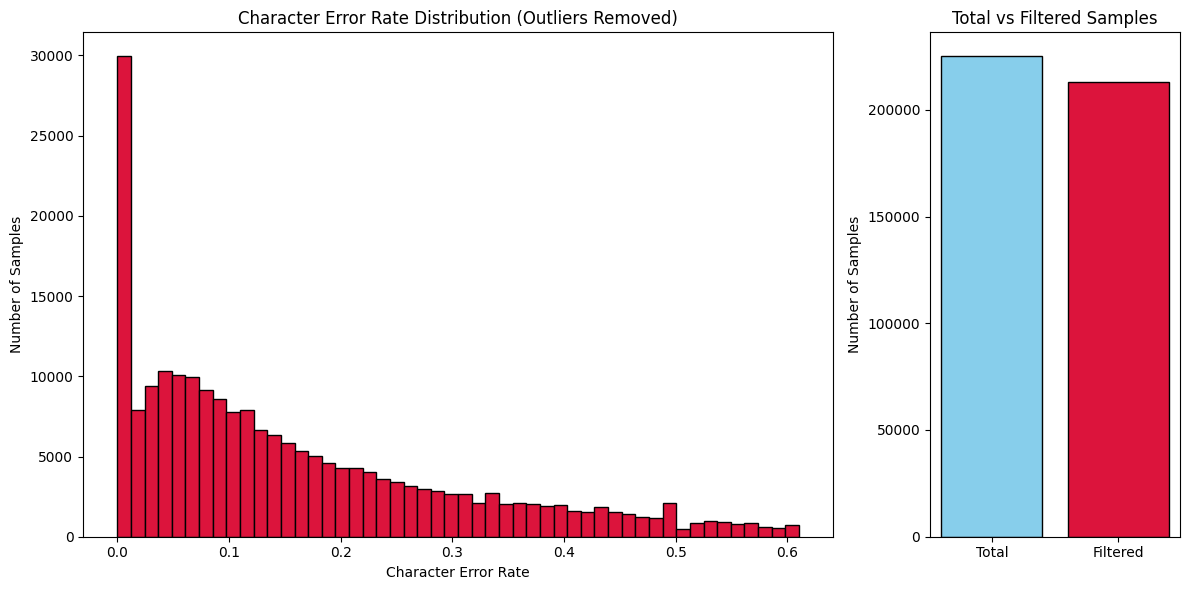

Outliers removed: 12119


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Compute Q1, Q3, and IQR
Q1 = np.percentile(cers, 25)
Q3 = np.percentile(cers, 75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
cers_filtered = [x for x in cers if lower_bound <= x <= upper_bound]

# Plot histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'width_ratios': [3, 1]})

# Left plot (75% width)
axes[0].hist(cers_filtered, bins=50, color='crimson', edgecolor='black')
axes[0].set_xlabel("Character Error Rate")
axes[0].set_ylabel("Number of Samples")
axes[0].set_title("Character Error Rate Distribution (Outliers Removed)")

# Right plot (25% width)
axes[1].bar(["Total", "Filtered"], [len(cers), len(cers_filtered)], color=['skyblue', 'crimson'], edgecolor='black')
axes[1].set_ylabel("Number of Samples")
axes[1].set_title("Total vs Filtered Samples")

plt.tight_layout()
plt.show()

print(f"Outliers removed: {len(cers) - len(cers_filtered)}")

In [22]:
df.to_csv('transcribed.csv', index=False)

In [20]:
speaker_n_files = {}
speaker_perfect_transcripts = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    speaker = row['filename'].split('/')[-2]
    if speaker not in speaker_n_files:
        speaker_n_files[speaker] = 1
        speaker_perfect_transcripts[speaker] = 0
    else:
        speaker_n_files[speaker] += 1
    
    if round(row['cer'], 2) == 0:
        speaker_perfect_transcripts[speaker] += 1

print(speaker_n_files)
print(speaker_perfect_transcripts)


100%|██████████| 225028/225028 [00:07<00:00, 31502.26it/s]

{'tc0864': 348, 'tc0744': 288, 'tc0948': 613, 'tc0745': 289, 'tc0131': 115, 'tc0191': 120, 'tc0802': 314, 'tc0487': 187, 'tc0574': 217, 'tc0512': 194, 'tc0257': 131, 'tc0658': 251, 'tc0708': 270, 'tc0917': 458, 'tc0411': 167, 'tc0171': 117, 'tc0391': 163, 'tc0199': 121, 'tc0284': 138, 'tc0640': 241, 'tc0143': 116, 'tc0102': 111, 'tc0642': 242, 'tc0400': 165, 'tc0736': 285, 'tc0889': 363, 'tc0930': 541, 'tc0405': 166, 'tc0283': 138, 'tc0575': 217, 'tc0715': 273, 'tc0721': 276, 'tc0231': 126, 'tc0810': 319, 'tc0436': 173, 'tc0215': 123, 'tc0773': 302, 'tc0198': 121, 'tc0349': 153, 'tc0467': 181, 'tc0107': 112, 'tc0183': 119, 'tc0766': 298, 'tc0274': 136, 'tc0850': 338, 'tc0530': 200, 'tc0072': 109, 'tc0344': 150, 'tc0228': 126, 'tc0396': 165, 'tc0910': 434, 'tc0422': 169, 'tc0181': 119, 'tc0779': 304, 'tc0521': 196, 'tc0870': 350, 'tc0984': 737, 'tc0394': 164, 'tc0899': 399, 'tc0247': 130, 'tc0490': 187, 'tc0726': 279, 'tc0506': 191, 'tc0913': 449, 'tc0768': 300, 'tc0015': 102, 'tc0967':

In [26]:
speaker_perfect_transcripts = dict(sorted(speaker_perfect_transcripts.items(), key=lambda x: x[1], reverse=True))
print(speaker_perfect_transcripts)

{'tc0965': 145, 'tc0984': 130, 'tc0982': 130, 'tc0968': 128, 'tc0979': 121, 'tc0962': 120, 'tc0955': 116, 'tc0953': 116, 'tc0948': 114, 'tc0969': 111, 'tc0981': 111, 'tc0947': 108, 'tc0956': 107, 'tc0941': 107, 'tc0923': 105, 'tc0954': 104, 'tc0983': 103, 'tc0951': 102, 'tc0892': 102, 'tc0938': 98, 'tc0946': 98, 'tc0957': 98, 'tc0937': 95, 'tc0939': 94, 'tc0949': 92, 'tc0910': 90, 'tc0967': 90, 'tc0942': 90, 'tc0889': 88, 'tc0902': 88, 'tc0920': 86, 'tc0788': 81, 'tc0940': 81, 'tc0932': 80, 'tc0973': 79, 'tc0909': 79, 'tc0944': 79, 'tc0925': 79, 'tc0860': 78, 'tc0795': 77, 'tc0963': 77, 'tc0913': 76, 'tc0976': 76, 'tc0930': 74, 'tc0725': 74, 'tc0945': 74, 'tc0885': 73, 'tc0914': 72, 'tc0959': 72, 'tc0770': 72, 'tc0798': 72, 'tc0837': 70, 'tc0783': 70, 'tc0849': 70, 'tc0906': 70, 'tc0980': 68, 'tc0669': 68, 'tc0905': 67, 'tc0926': 67, 'tc0855': 67, 'tc0876': 67, 'tc0971': 67, 'tc0978': 67, 'tc0875': 66, 'tc0933': 66, 'tc0919': 66, 'tc0883': 65, 'tc0934': 65, 'tc0915': 64, 'tc0865': 64, 

In [28]:
for speaker in speaker_perfect_transcripts:
    if speaker_perfect_transcripts[speaker] >= 100:
        print(f"Speaker {speaker} has {speaker_perfect_transcripts[speaker]} perfect transcripts out of {speaker_n_files[speaker]} files")

Speaker tc0965 has 145 perfect transcripts out of 648 files
Speaker tc0984 has 130 perfect transcripts out of 737 files
Speaker tc0982 has 130 perfect transcripts out of 730 files
Speaker tc0968 has 128 perfect transcripts out of 652 files
Speaker tc0979 has 121 perfect transcripts out of 693 files
Speaker tc0962 has 120 perfect transcripts out of 642 files
Speaker tc0955 has 116 perfect transcripts out of 622 files
Speaker tc0953 has 116 perfect transcripts out of 617 files
Speaker tc0948 has 114 perfect transcripts out of 613 files
Speaker tc0969 has 111 perfect transcripts out of 654 files
Speaker tc0981 has 111 perfect transcripts out of 728 files
Speaker tc0947 has 108 perfect transcripts out of 612 files
Speaker tc0956 has 107 perfect transcripts out of 624 files
Speaker tc0941 has 107 perfect transcripts out of 595 files
Speaker tc0923 has 105 perfect transcripts out of 502 files
Speaker tc0954 has 104 perfect transcripts out of 621 files
Speaker tc0983 has 103 perfect transcrip

In [24]:
ratios = {}
for speaker in speaker_perfect_transcripts:
    ratios[speaker] = speaker_perfect_transcripts[speaker] / speaker_n_files[speaker]

# sort by value
ratios = dict(sorted(ratios.items(), key=lambda item: item[1], reverse=True))
print(ratios)

{'tc0100': 0.32432432432432434, 'tc0165': 0.2905982905982906, 'tc0892': 0.2749326145552561, 'tc0669': 0.2677165354330709, 'tc0725': 0.26523297491039427, 'tc0788': 0.262987012987013, 'tc0483': 0.2620320855614973, 'tc0389': 0.25925925925925924, 'tc0269': 0.2537313432835821, 'tc0268': 0.2537313432835821, 'tc0006': 0.25, 'tc0281': 0.24817518248175183, 'tc0222': 0.248, 'tc0166': 0.24786324786324787, 'tc0795': 0.24758842443729903, 'tc0411': 0.24550898203592814, 'tc0047': 0.24528301886792453, 'tc0271': 0.24444444444444444, 'tc0623': 0.24358974358974358, 'tc0558': 0.24285714285714285, 'tc0889': 0.24242424242424243, 'tc0312': 0.2413793103448276, 'tc0770': 0.24, 'tc0409': 0.23952095808383234, 'tc0348': 0.23684210526315788, 'tc0457': 0.23595505617977527, 'tc0555': 0.23557692307692307, 'tc0645': 0.2336065573770492, 'tc0637': 0.23333333333333334, 'tc0207': 0.23140495867768596, 'tc0798': 0.23076923076923078, 'tc0488': 0.22994652406417113, 'tc0443': 0.22988505747126436, 'tc0783': 0.22875816993464052,

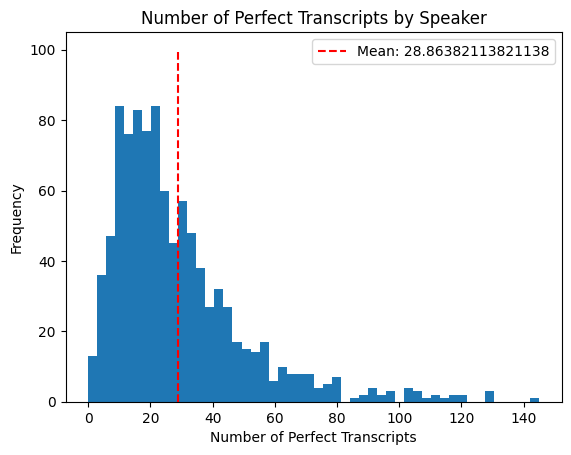

In [31]:
# plt hist by speaker
mean_perfect_transcripts = np.mean(list(speaker_perfect_transcripts.values()))
plt.hist(speaker_perfect_transcripts.values(), bins=50)
plt.vlines(mean_perfect_transcripts, 0, 100, colors='r', linestyles='dashed', label=f'Mean: {mean_perfect_transcripts}')
plt.legend()
plt.xlabel("Number of Perfect Transcripts")
plt.ylabel("Frequency")
plt.title("Number of Perfect Transcripts by Speaker")
plt.show()

In [37]:
qualified_speakers = []
for speaker in speaker_perfect_transcripts:
    n_perfect = speaker_perfect_transcripts[speaker]
    if n_perfect >= 20:
        qualified_speakers.append(speaker)

print(qualified_speakers)
print(len(qualified_speakers))

['tc0965', 'tc0984', 'tc0982', 'tc0968', 'tc0979', 'tc0962', 'tc0955', 'tc0953', 'tc0948', 'tc0969', 'tc0981', 'tc0947', 'tc0956', 'tc0941', 'tc0923', 'tc0954', 'tc0983', 'tc0951', 'tc0892', 'tc0938', 'tc0946', 'tc0957', 'tc0937', 'tc0939', 'tc0949', 'tc0910', 'tc0967', 'tc0942', 'tc0889', 'tc0902', 'tc0920', 'tc0788', 'tc0940', 'tc0932', 'tc0973', 'tc0909', 'tc0944', 'tc0925', 'tc0860', 'tc0795', 'tc0963', 'tc0913', 'tc0976', 'tc0930', 'tc0725', 'tc0945', 'tc0885', 'tc0914', 'tc0959', 'tc0770', 'tc0798', 'tc0837', 'tc0783', 'tc0849', 'tc0906', 'tc0980', 'tc0669', 'tc0905', 'tc0926', 'tc0855', 'tc0876', 'tc0971', 'tc0978', 'tc0875', 'tc0933', 'tc0919', 'tc0883', 'tc0934', 'tc0915', 'tc0865', 'tc0785', 'tc0736', 'tc0867', 'tc0970', 'tc0784', 'tc0898', 'tc0887', 'tc0813', 'tc0723', 'tc0759', 'tc0943', 'tc0710', 'tc0952', 'tc0804', 'tc0843', 'tc0918', 'tc0928', 'tc0658', 'tc0960', 'tc0924', 'tc0972', 'tc0907', 'tc0623', 'tc0645', 'tc0890', 'tc0745', 'tc0917', 'tc0866', 'tc0975', 'tc0655',

In [40]:
qualified_files = []
for i, row in tqdm(df.iterrows(), total=len(df)):
    speaker = row['filename'].split('/')[-2]
    if speaker in qualified_speakers and round(row['cer'], 2) == 0:
        qualified_files.append(row['filename'])

# save to file
with open('qualified_files.txt', 'w') as f:
    for file in qualified_files:
        f.write(f"{file}\n")


100%|██████████| 225028/225028 [00:08<00:00, 27612.00it/s]


In [41]:
print(len(qualified_files))

23824
